In [1]:
# End-to-End CNN Image Classifier for Amazon Fruits Dataset

# STEP 0: Mount Google Drive & Upload Dataset

# Run this cell first to mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')


# For direct upload to /content:
import shutil, os

zip_path = '/content/FruitinAmazon.zip'


# STEP 1: Extract the ZIP

import zipfile

extract_dir = '/content/FruitinAmazon'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extraction complete!")
print("Directory structure:")
for root, dirs, files_list in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:3]:   # show first 3 files per folder
            print(f'{subindent}{f}')

ModuleNotFoundError: No module named 'google'

Number of classes found: 6
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


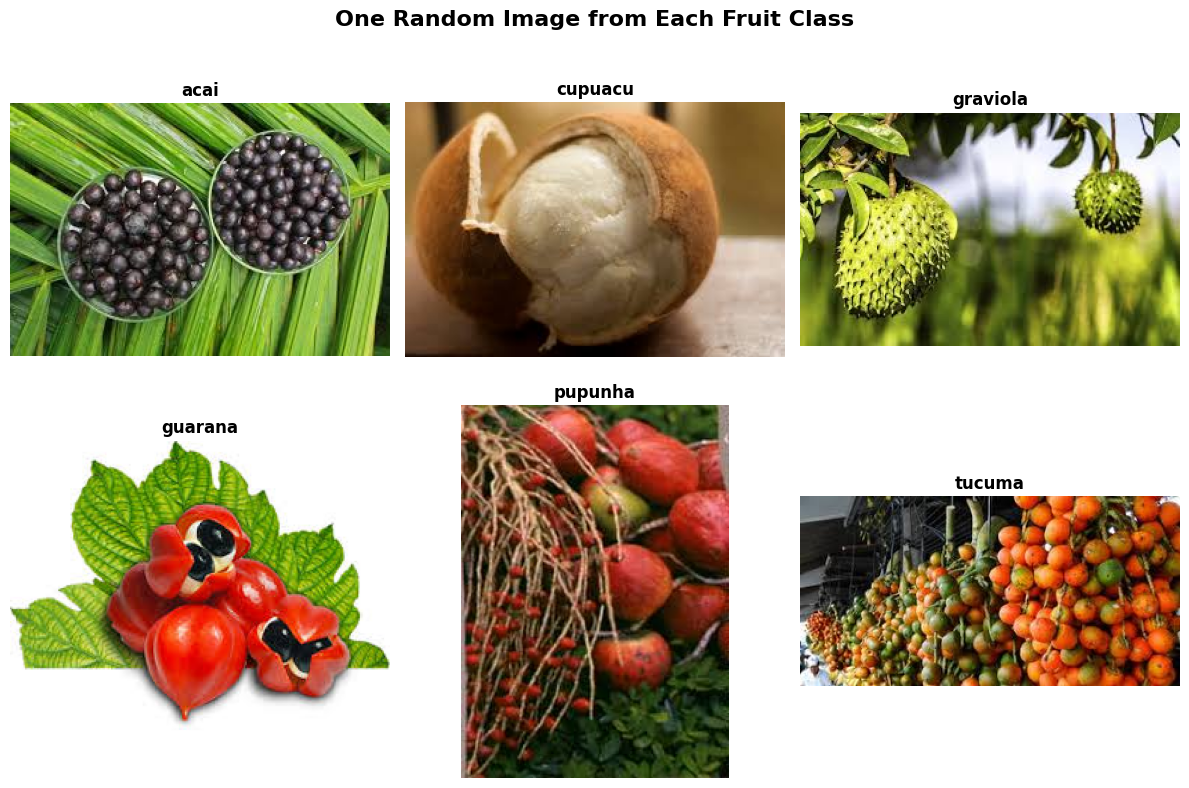

In [6]:

# TASK 1 – Part 1: Data Understanding and Visualization
# Load and visualize one random image from each class

import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define train directory path
train_dir = '/content/FruitinAmazon/train'

# Step 1: Get list of all class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Number of classes found: {len(class_dirs)}")
print(f"Classes: {class_dirs}")

# Step 2: Randomly select one image from each class
selected_images = []
for cls in class_dirs:
    cls_path = os.path.join(train_dir, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    # Randomly pick one image from this class
    chosen = random.choice(images)
    selected_images.append((cls, os.path.join(cls_path, chosen)))

# Step 3: Display images in a grid with 2 rows using matplotlib
num_classes = len(selected_images)
cols = (num_classes + 1) // 2   # columns per row so we get 2 rows
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for idx, (cls_name, img_path) in enumerate(selected_images):
    img = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls_name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

# Hide any extra subplots if classes < total cells
for idx in range(len(selected_images), len(axes)):
    axes[idx].axis('off')

plt.suptitle('One Random Image from Each Fruit Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:

# TASK 1 - Part 2: Check for Corrupted Images

from PIL import Image

def check_and_remove_corrupted(directory):
    """
    Iterates through all images in the given directory (recursively).
    If a corrupted image is found (IOError or SyntaxError when opening),
    it removes that image and prints a message.
    """
    corrupted_images = []   # List to track all corrupted image paths

    # Walk through all subdirectories
    for root, dirs, files_list in os.walk(directory):
        for fname in files_list:
            if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                image_path = os.path.join(root, fname)
                try:
                    # Attempt to open and verify the image
                    with Image.open(image_path) as img:
                        img.verify()   # verify checks for corruption without fully loading
                except (IOError, SyntaxError) as e:
                    # Image is corrupted — remove it and log
                    corrupted_images.append(image_path)
                    os.remove(image_path)
                    print(f"Removed corrupted image: {image_path}")

    # Final report
    if not corrupted_images:
        print("No Corrupted Images Found.")
    else:
        print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

    return corrupted_images

# Run corruption check on the train directory
print("Checking train directory for corrupted images...")
corrupted = check_and_remove_corrupted(train_dir)

Checking train directory for corrupted images...
No Corrupted Images Found.


In [8]:
# TASK 2: Loading and Preprocessing Image Data in Keras

import tensorflow as tf
import numpy as np

# Define paths
train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

# Hyperparameters for data loading
img_height       = 128    # Resize all images to 128x128
img_width        = 128
batch_size       = 32
validation_split = 0.2    # 80% train, 20% validation

# Normalization layer: scale pixel values from [0,255] to [0,1]
rescale = tf.keras.layers.Rescaling(1.0 / 255)

#  Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',          # Labels inferred from subdirectory names
    label_mode='int',           # Integer labels (0, 1, 2, ...)
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,               # Shuffle training data
    validation_split=validation_split,
    subset='training',
    seed=123                    # For reproducibility
)

# Apply normalization to training dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,              # Do NOT shuffle validation data
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test Dataset
# Load test images from the separate test directory (no split needed)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False               # Keep order for evaluation
)

# Apply normalization to test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Get class names from the training dataset
class_names = train_ds.class_names if hasattr(train_ds, 'class_names') else sorted(os.listdir(train_dir))
num_classes = len(class_names)

print(f"Class Names : {class_names}")
print(f"Num Classes : {num_classes}")
print(f"Train batches     : {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches      : {len(test_ds)}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class Names : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num Classes : 6
Train batches     : 3
Validation batches: 1
Test batches      : 1


In [ ]:
# TASK 3: Build the CNN Model

from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(128, 128, 3), num_classes=6):
    """
    Builds a CNN model following the architecture defined in Worksheet-5.

    Convolutional Block 1:
        Conv2D(32, 3x3, same, stride=1) - ReLU - MaxPool(2x2, stride=2)
    Convolutional Block 2:
        Conv2D(32, 3x3, same, stride=1) - ReLU - MaxPool(2x2, stride=2)
    Fully Connected:
        Flatten - Dense(128, ReLU) - Dense(64, ReLU) - Dense(num_classes, Softmax)
    """

    model = models.Sequential([

        # Convolutional Layer 1
        # 32 filters, 3x3 kernel, 'same' padding, stride=1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding='same',
            activation='relu',
            input_shape=input_shape,
            name='Conv1'
        ),

        #  Pooling Layer 1
        # MaxPool 2x2, stride=2 - halves spatial dimensions
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2),
            name='MaxPool1'
        ),

        #  Convolutional Layer 2
        # 32 filters, 3x3 kernel, 'same' padding, stride=1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            strides=(1, 1),
            padding='same',
            activation='relu',
            name='Conv2'
        ),

        #  Pooling Layer 2
        # MaxPool 2x2, stride=2 - halves spatial dimensions again
        layers.MaxPooling2D(
            pool_size=(2, 2),
            strides=(2, 2),
            name='MaxPool2'
        ),

        #  Flatten Layer
        # Converts 3D feature maps - 1D vector for fully connected layers
        layers.Flatten(name='Flatten'),

        #  Hidden Layer 1 (Dense 128)
        layers.Dense(128, activation='relu', name='Dense_128'),

        #  Hidden Layer 2 (Dense 64)
        layers.Dense(64, activation='relu', name='Dense_64'),

        # Output Layer
        # num_classes neurons with Softmax - probability distribution over classes
        layers.Dense(num_classes, activation='softmax', name='Output')
    ])

    return model

# Build the model
model = build_cnn_model(input_shape=(img_height, img_width, 3), num_classes=num_classes)

# Print model architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# TASK 4: Compile the Model

model.compile(
    optimizer='adam',                          # Adam optimizer: adaptive learning rate
    loss='sparse_categorical_crossentropy',    # Used when labels are integers (not one-hot)
    metrics=['accuracy']                       # Track accuracy during training
)

print("Model compiled successfully!")
print(f"  Optimizer : Adam")
print(f"  Loss      : sparse_categorical_crossentropy")
print(f"  Metric    : accuracy")

Model compiled successfully!
  Optimizer : Adam
  Loss      : sparse_categorical_crossentropy
  Metric    : accuracy


In [ ]:
# TASK 4: Train the Model

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callback 1: ModelCheckpoint
# Saves the best model (based on val_accuracy) during training
checkpoint_cb = ModelCheckpoint(
    filepath='best_fruit_cnn_model.h5',   # Save to .h5 file
    monitor='val_accuracy',               # Monitor validation accuracy
    save_best_only=True,                  # Only save when val_accuracy improves
    verbose=1
)

# Callback 2: EarlyStopping
# Stops training if val_accuracy doesn't improve for 'patience' epochs
# This prevents overfitting and wasted computation
early_stop_cb = EarlyStopping(
    monitor='val_accuracy',    # Monitor validation accuracy
    patience=15,               # Stop after 15 epochs with no improvement
    restore_best_weights=True, # Restore weights from best epoch on stop
    verbose=1
)

# Train the Model
# batch_size=16 and epochs=250 as specified in the worksheet
# EarlyStopping will halt training early if the model stops improving
history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,             
                               # actual batch size was set in image_dataset_from_directory
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

print("\nTraining complete!")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.1649 - loss: 2.0979
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn_model.h5



Epoch 1: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1667 - loss: 2.2626 - val_accuracy: 0.0000e+00 - val_loss: 2.0221
Epoch 2/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2188 - loss: 1.6966
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_fruit_cnn_model.h5



Epoch 2: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1806 - loss: 1.7093 - val_accuracy: 0.4444 - val_loss: 1.4424
Epoch 3/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4062 - loss: 1.5784
Epoch 3: val_accuracy improved from 0.44444 to 0.66667, saving model to best_fruit_cnn_model.h5



Epoch 3: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4167 - loss: 1.4552 - val_accuracy: 0.6667 - val_loss: 1.4578
Epoch 4/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 1.3511
Epoch 4: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5278 - loss: 1.2487 - val_accuracy: 0.5556 - val_loss: 1.2923
Epoch 5/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7812 - loss: 0.8756
Epoch 5: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6806 - loss: 0.9795 - val_accuracy: 0.6667 - val_loss: 1.0494
Epoch 6/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7188 - loss: 0.8028
Epoch 6: val_accuracy improved from 0.66667 to 0.77778, saving model to best_fruit_cnn_model.h5



Epoch 6: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.6528 - loss: 0.7781 - val_accuracy: 0.7778 - val_loss: 0.7014
Epoch 7/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9062 - loss: 0.4749
Epoch 7: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8750 - loss: 0.5112 - val_accuracy: 0.6667 - val_loss: 1.0684
Epoch 8/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8438 - loss: 0.4445
Epoch 8: val_accuracy improved from 0.77778 to 0.88889, saving model to best_fruit_cnn_model.h5



Epoch 8: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8889 - loss: 0.3977 - val_accuracy: 0.8889 - val_loss: 0.4834
Epoch 9/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.2197
Epoch 9: val_accuracy improved from 0.88889 to 0.94444, saving model to best_fruit_cnn_model.h5



Epoch 9: finished saving model to best_fruit_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.2311 - val_accuracy: 0.9444 - val_loss: 0.4185
Epoch 10/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.1404
Epoch 10: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.1279 - val_accuracy: 0.7222 - val_loss: 0.6492
Epoch 11/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9688 - loss: 0.1338
Epoch 11: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9722 - loss: 0.0907 - val_accuracy: 0.8889 - val_loss: 0.4980
Epoch 12/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0382
Epoch 12: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0484 - val_accuracy: 0.8889 - val_loss: 0.3912
Epoch 13/250
1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - l

In [12]:
# TASK 5: Evaluate the Model

# Evaluate on the test set using model.evaluate()
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Evaluating model on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step - accuracy: 0.7667 - loss: 0.7936
  Test Loss     : 0.7936
  Test Accuracy : 0.7667 (76.67%)


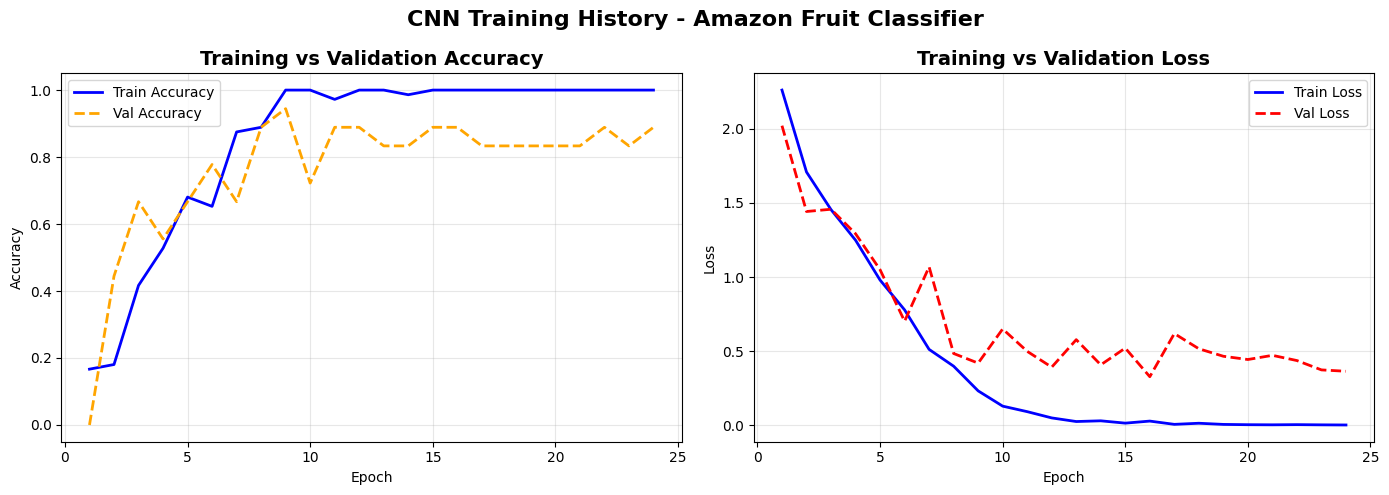

Training history plot saved as 'training_history.png'


In [13]:
# VISUALIZATION: Training & Validation Loss and Accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Plot 1: Accuracy
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy', color='blue',   linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Val Accuracy',   color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss
axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss', color='blue',   linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   color='red',    linewidth=2, linestyle='--')
axes[1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training History - Amazon Fruit Classifier', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved as 'training_history.png'")

In [14]:
# TASK 6: Save and Load the Model

# Save the trained model
model_save_path = 'fruit_cnn_model.h5'
model.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# Load the saved model
from tensorflow.keras.models import load_model

loaded_model = load_model(model_save_path)
print(f"Model loaded successfully from: {model_save_path}")

# Re-evaluate the loaded model on the test set
print("\nRe-evaluating the loaded model on test set...")
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"  Loaded Model Test Loss     : {loaded_test_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_test_acc:.4f} ({loaded_test_acc*100:.2f}%)")

Model saved to: fruit_cnn_model.h5


Model loaded successfully from: fruit_cnn_model.h5

Re-evaluating the loaded model on test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7667 - loss: 0.7936
  Loaded Model Test Loss     : 0.7936
  Loaded Model Test Accuracy : 0.7667 (76.67%)


Total test samples  : 30
Sample true labels  : [0 0 0 0 0 1 1 1 1 1]
Sample pred labels  : [0 1 0 0 0 1 2 2 1 1]
         CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.62      1.00      0.77         5
     guarana       0.83      1.00      0.91         5
     pupunha       1.00      0.80      0.89         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.77        30
   macro avg       0.81      0.77      0.76        30
weighted avg       0.81      0.77      0.76        30



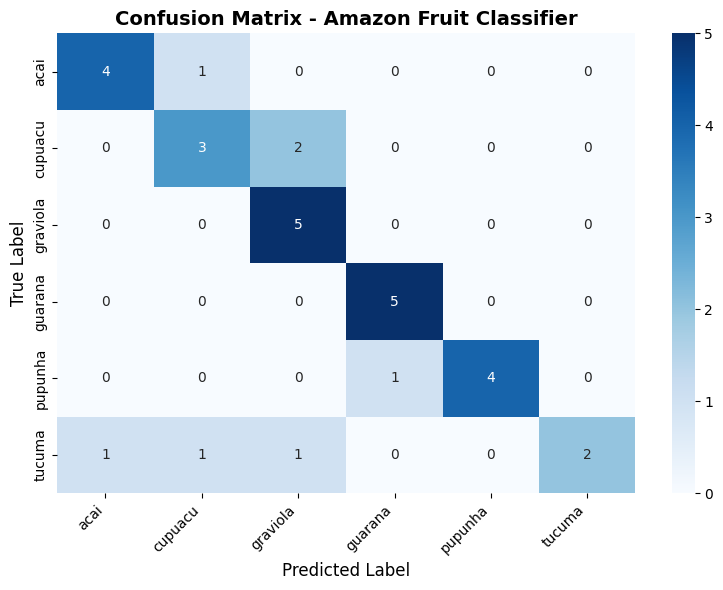

Confusion matrix saved as 'confusion_matrix.png'


In [15]:
# TASK 7: Predictions and Classification Report

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Collect all true labels and predictions from test_ds
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    # Get predicted probabilities for each batch
    preds = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

# Convert probabilities -> predicted class labels using argmax
y_true      = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred      = np.argmax(y_pred_probs, axis=1)   # Pick class with highest probability

print(f"Total test samples  : {len(y_true)}")
print(f"Sample true labels  : {y_true[:10]}")
print(f"Sample pred labels  : {y_pred[:10]}")

# Classification Report
print("         CLASSIFICATION REPORT")
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names   # Use actual fruit class names
)
print(report)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - Amazon Fruit Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

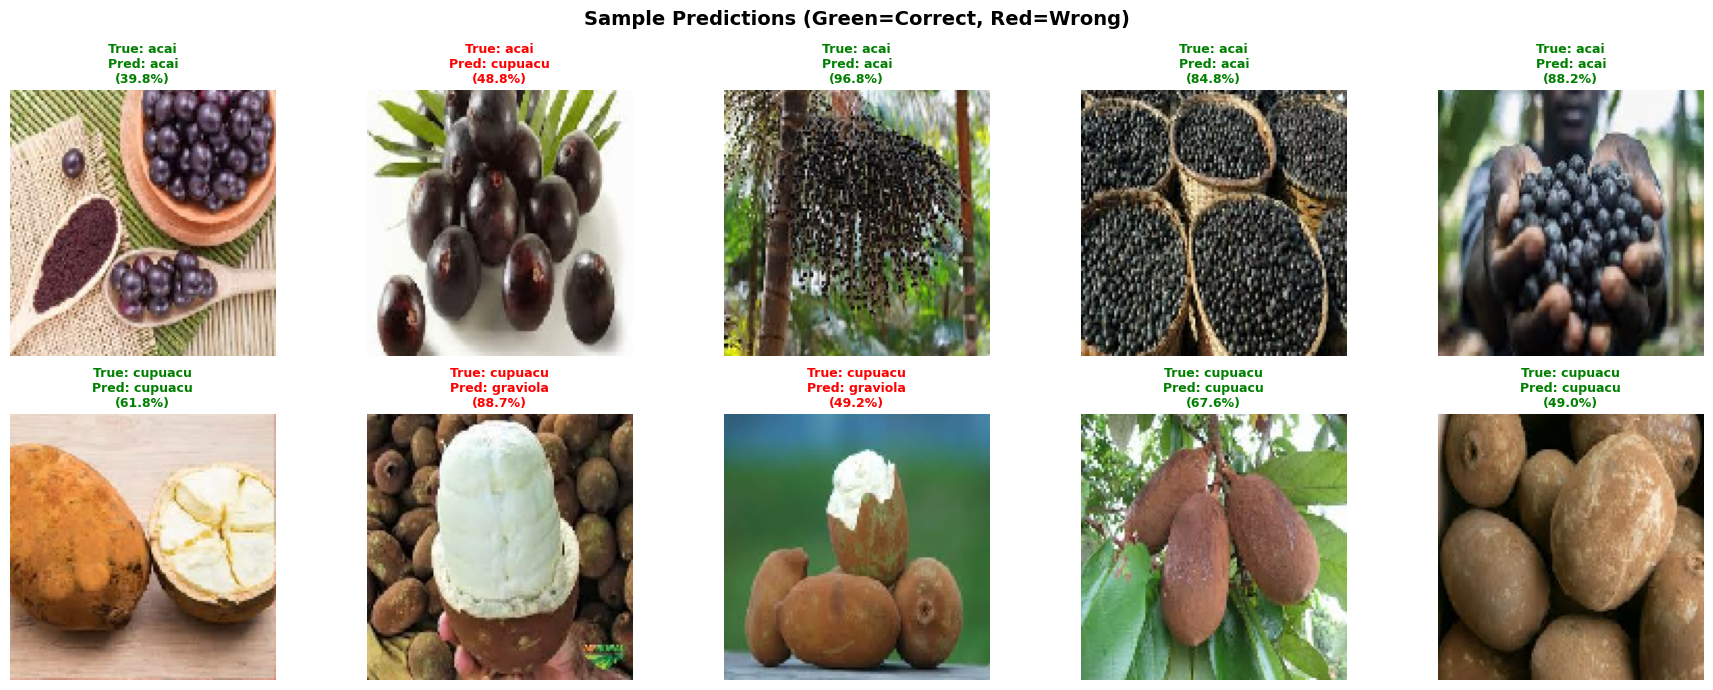

Sample predictions saved as 'sample_predictions.png'


In [16]:
# Visualize Sample Predictions on Test Images

# Grab one batch of test images
test_images, test_labels = next(iter(test_ds))

# Make predictions on this batch
predictions = loaded_model.predict(test_images, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

# Show 10 sample predictions
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(10):
    img = test_images[i].numpy()
    true_label = class_names[test_labels[i]]
    pred_label = class_names[predicted_labels[i]]
    confidence = predictions[i][predicted_labels[i]] * 100

    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\n({confidence:.1f}%)",
        color=color, fontsize=9, fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample predictions saved as 'sample_predictions.png'")